**MLP**


---

Initial implementation by - **Vrutant Chaudhari**

Extended with additional evaluation metrices (ROC Curve, F1-Score, etc.) # New Section

In [27]:
#############################
#      NOTEBOOK SETTINGS    #
#############################

USE_AUGMENTATION = True
N_SYNTH_SAMPLES = None
RUN_KFOLD = True
KFOLD_SPLITS = 5
USE_UNSCALED = True

In [28]:
#############################
#       MOUNT GOOGLE DRIVE  #
#############################

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
#############################
#      PROJECT SETTINGS     #
#############################

import os

PROJECT_ROOT = "/content/drive/MyDrive/ML Group Project CSCI 635"
DATA_FILE = os.path.join(PROJECT_ROOT, "data", "wfh_burnout_dataset.csv")

print("Project root:", PROJECT_ROOT)
print("Data file:", DATA_FILE)
print("Dataset exists:", os.path.exists(DATA_FILE))


Project root: /content/drive/MyDrive/ML Group Project CSCI 635
Data file: /content/drive/MyDrive/ML Group Project CSCI 635/data/wfh_burnout_dataset.csv
Dataset exists: True


In [30]:
#############################
#       IMPORT LIBRARIES    #
#############################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.neighbors import KernelDensity
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_curve,
    auc
)


In [31]:
#############################
#      GLOBAL SETTINGS      #
#############################

RANDOM_STATE = 35
NUM_TARGET_CLASSES = 3
BATCH_SIZE = 64
LEARNING_RATE = 0.001
NUM_EPOCHS = 150
PATIENCE = 15
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Device:", DEVICE)


Device: cpu


In [32]:
#############################
#       LOAD DATASET        #
#############################

data = pd.read_csv(DATA_FILE)
print("Dataset shape:", data.shape)
data.head()


Dataset shape: (2000, 14)


,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,app_switches,sleep_hours,task_completion,isolation_index,fatigue_score,burnout_score,burnout_risk
0,129,Weekday,7.74,5.99,3,7,0,50,7.50,74.80,4,3.51,17.23,Low
1,24,Weekday,8.48,7.23,3,5,0,63,7.31,86.36,4,5.15,24.01,Low
2,147,Weekend,8.39,7.14,1,5,0,27,6.73,89.23,8,7.85,51.46,Medium
3,42,Weekday,12.48,12.23,4,1,1,89,6.55,64.47,5,10.00,55.50,Medium
4,99,Weekend,8.85,7.35,4,6,0,40,8.03,98.62,3,3.45,11.95,Low


In [33]:
#############################
#      PREPROCESS DATA      #
#############################

def preprocess_dataset(dataframe):
    df = dataframe.copy()
    df = pd.get_dummies(df, columns=["day_type"], drop_first=True)
    df["burnout_risk"] = df["burnout_risk"].map({"High": 2, "Medium": 1, "Low": 0})

    X = df.drop(["burnout_risk", "burnout_score", "user_id"], axis=1)
    y = df["burnout_risk"]
    return X, y

X, y = preprocess_dataset(data)

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())
print(y.value_counts().sort_index())


X shape: (2000, 11)
y shape: (2000,)


,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,app_switches,sleep_hours,task_completion,isolation_index,fatigue_score,day_type_Weekend
0,7.74,5.99,3,7,0,50,7.50,74.80,4,3.51,False
1,8.48,7.23,3,5,0,63,7.31,86.36,4,5.15,False
2,8.39,7.14,1,5,0,27,6.73,89.23,8,7.85,True
3,12.48,12.23,4,1,1,89,6.55,64.47,5,10.00,False
4,8.85,7.35,4,6,0,40,8.03,98.62,3,3.45,True


burnout_risk
0    1019
1     843
2     138
Name: count, dtype: int64


In [34]:
#############################
#     TRAIN/TEST SPLIT      #
#############################

def train_test(split=0.2):
    X, y = preprocess_dataset(pd.read_csv(DATA_FILE))

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=split,
        stratify=y,
        random_state=42
    )
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = train_test()

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(1600, 11) (400, 11) (1600,) (400,)


In [35]:
#############################
#    AUGMENTATION HELPERS   #
#############################

def generate_synthetic_data(X, y, n_samples=2000, rand_state=11):
    y = y.squeeze()
    y_arr = y.values.reshape(-1)
    classes, counts = np.unique(y_arr, return_counts=True)

    kdes = {}
    bandwidth_params = {"bandwidth": np.arange(0.01, 1, 0.05)}

    for cls in classes:
        X_cls = X[y_arr == cls]
        grid_search = GridSearchCV(KernelDensity(), bandwidth_params, cv=5)
        grid_search.fit(X_cls.values)
        kdes[cls] = grid_search.best_estimator_

    freqs = counts / counts.sum()
    samples_per_class = np.floor(freqs * n_samples).astype(int)

    remainder = n_samples - samples_per_class.sum()
    if remainder > 0:
        idxs = np.argsort(-counts)
        for i in range(remainder):
            samples_per_class[idxs[i % len(classes)]] += 1

    new_X = []
    new_y = []

    for cls, n in zip(classes, samples_per_class):
        new_data = kdes[cls].sample(n, random_state=rand_state)
        new_X.append(new_data)
        new_y.append(np.full(n, cls))

    X_synth = np.vstack(new_X)
    y_synth = np.concatenate(new_y)

    df_X_synth = pd.DataFrame(X_synth, columns=X.columns)
    df_y_synth = pd.Series(y_synth)

    return df_X_synth, df_y_synth


def _apply_constraints(df, constraints):
    if not constraints:
        return df

    df = df.copy()

    for col, spec in constraints.items():
        if col not in df.columns:
            continue

        vals = df[col].astype(float).to_numpy()
        t = spec.get("type")

        if t == "categorical":
            allowed = np.array(spec.get("values", []))
            if allowed.size == 0:
                continue
            idx = np.abs(vals[:, None] - allowed[None, :]).argmin(axis=1)
            df[col] = allowed[idx]

        elif t == "int":
            ints = np.rint(vals).astype(int)
            mn = spec.get("min", ints.min())
            mx = spec.get("max", ints.max())
            df[col] = np.clip(ints, mn, mx)

        elif t == "float":
            mn = spec.get("min", vals.min())
            mx = spec.get("max", vals.max())
            df[col] = np.clip(vals, mn, mx)

    return df


def augment_training_data(X, y, n_samples=2000):
    df_X_synth, df_y_synth = generate_synthetic_data(X, y, n_samples=n_samples)
    X_aug = pd.concat([X, df_X_synth], ignore_index=True)
    y_aug = pd.concat([y.squeeze(), df_y_synth], ignore_index=True)
    return X_aug, y_aug


def augment_training_data_unscaled(X, y, n_samples=2000):
    y = y.squeeze() if isinstance(y, pd.DataFrame) else y

    df_X_synth, df_y_synth = generate_synthetic_data(X, y, n_samples=n_samples)

    constraints = {
        "day_type_Weekend": {"type": "categorical", "values": [0, 1]},
        "work_hours": {"type": "float", "min": 0.5, "max": 18},
        "screen_time_hours": {"type": "float", "min": 0, "max": 18},
        "meetings_count": {"type": "int", "min": 0, "max": 20},
        "breaks_taken": {"type": "int", "min": 0, "max": 15},
        "after_hours_work": {"type": "categorical", "values": [0, 1]},
        "app_switches": {"type": "int", "min": 5, "max": 200},
        "sleep_hours": {"type": "float", "min": 3, "max": 10},
        "task_completion": {"type": "float", "min": 0, "max": 100},
        "isolation_index": {"type": "int", "min": 3, "max": 9},
        "fatigue_score": {"type": "float", "min": 0, "max": 10},
    }

    df_X_synth = _apply_constraints(df_X_synth, constraints)

    X_aug = pd.concat([X, df_X_synth], ignore_index=True)
    y_aug = pd.concat([y.squeeze(), df_y_synth], ignore_index=True)

    return X_aug, y_aug


In [36]:
#############################
#       DEFINE MLP MODEL    #
#############################

class PyTorchMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, num_classes=3, dropout_rate=0.0):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x


In [37]:
#############################
#   TRAINING HELPER FUNCS   #
#############################

def regularization_penalty(model, l1_lambda=0.0):
    penalty = 0.0
    if l1_lambda > 0:
        penalty += l1_lambda * sum(param.abs().sum() for param in model.parameters())
    return penalty


def run_epoch(model, loader, criterion, optimizer=None, l1_lambda=0.0):
    training = optimizer is not None

    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss = loss + regularization_penalty(model, l1_lambda)

            if training:
                loss.backward()
                optimizer.step()

        preds = torch.argmax(logits, dim=1)
        total_loss += loss.item() * X_batch.size(0)
        total_correct += (preds == y_batch).sum().item()
        total_samples += y_batch.size(0)

    epoch_loss = total_loss / total_samples
    epoch_acc = total_correct / total_samples
    return epoch_loss, epoch_acc


def train_model(
    model,
    train_loader,
    val_loader,
    learning_rate=0.001,
    num_epochs=100,
    l1_lambda=0.0,
    l2_lambda=0.0,
    early_stopping=False,
    patience=10
):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=l2_lambda
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_val_loss = float("inf")
    best_state_dict = None
    wait = 0

    model.to(DEVICE)

    for epoch in range(num_epochs):
        train_loss, train_acc = run_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            l1_lambda=l1_lambda
        )

        val_loss, val_acc = run_epoch(
            model=model,
            loader=val_loader,
            criterion=criterion,
            optimizer=None,
            l1_lambda=l1_lambda
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if early_stopping:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    print(f"Early stopping at epoch {epoch + 1}")
                    break

    if early_stopping and best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return model, history


def predict_model(model, X_tensor):
    model.eval()
    model.to(DEVICE)

    with torch.no_grad():
        logits = model(X_tensor.to(DEVICE))
        probabilities = torch.softmax(logits, dim=1).cpu().numpy()
        predictions = np.argmax(probabilities, axis=1)

    return predictions, probabilities


In [38]:
#############################
#   MODEL CONFIGURATIONS    #
#############################

def get_model_configs():
    return {
        "Baseline MLP": {
            "dropout_rate": 0.0,
            "l1_lambda": 0.0,
            "l2_lambda": 0.0,
            "early_stopping": False
        },
        "Dropout MLP": {
            "dropout_rate": 0.3,
            "l1_lambda": 0.0,
            "l2_lambda": 0.0,
            "early_stopping": False
        },
        "L1 MLP": {
            "dropout_rate": 0.0,
            "l1_lambda": 1e-5,
            "l2_lambda": 0.0,
            "early_stopping": False
        },
        "L2 MLP": {
            "dropout_rate": 0.0,
            "l1_lambda": 0.0,
            "l2_lambda": 1e-4,
            "early_stopping": False
        },
        "L1 + L2 MLP": {
            "dropout_rate": 0.0,
            "l1_lambda": 1e-5,
            "l2_lambda": 1e-4,
            "early_stopping": False
        },
        "Full Regularized MLP": {
            "dropout_rate": 0.3,
            "l1_lambda": 1e-5,
            "l2_lambda": 1e-4,
            "early_stopping": True
        }
    }


def train_all_models(input_dim, train_loader, val_loader):
    model_configs = get_model_configs()
    models = {}
    histories = {}

    for name, config in model_configs.items():
        model = PyTorchMLP(
            input_dim=input_dim,
            hidden_dim=32,
            num_classes=NUM_TARGET_CLASSES,
            dropout_rate=config["dropout_rate"]
        )

        trained_model, history = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            learning_rate=LEARNING_RATE,
            num_epochs=NUM_EPOCHS,
            l1_lambda=config["l1_lambda"],
            l2_lambda=config["l2_lambda"],
            early_stopping=config["early_stopping"],
            patience=PATIENCE
        )

        models[name] = trained_model
        histories[name] = history

    return models, histories


In [39]:
#############################
#      DATA PREPARATION     #
#############################

X_train, X_test, y_train, y_test = train_test()

y_train = y_train.squeeze() if isinstance(y_train, pd.DataFrame) else y_train
y_test = y_test.squeeze() if isinstance(y_test, pd.DataFrame) else y_test

if USE_AUGMENTATION:
    print("Using augmented training data")
    synth_n = len(X_train) if N_SYNTH_SAMPLES is None else N_SYNTH_SAMPLES

    if USE_UNSCALED:
        print("Augmentation type: UNSCALED")
        X_train_aug_raw, y_train = augment_training_data_unscaled(
            X_train,
            y_train,
            n_samples=synth_n
        )

        scaler = StandardScaler()
        X_train = pd.DataFrame(
            scaler.fit_transform(X_train_aug_raw),
            columns=X_train.columns
        )
        X_test = pd.DataFrame(
            scaler.transform(X_test),
            columns=X_train.columns
        )

    else:
        print("Augmentation type: SCALED")
        scaler = StandardScaler()
        X_train_scaled = pd.DataFrame(
            scaler.fit_transform(X_train),
            columns=X_train.columns
        )
        X_test_scaled = pd.DataFrame(
            scaler.transform(X_test),
            columns=X_train.columns
        )

        X_train, y_train = augment_training_data(
            X_train_scaled,
            y_train,
            n_samples=synth_n
        )
        X_test = X_test_scaled

else:
    print("Using non-augmented training data")
    scaler = StandardScaler()
    X_train = pd.DataFrame(
        scaler.fit_transform(X_train),
        columns=X_train.columns
    )
    X_test = pd.DataFrame(
        scaler.transform(X_test),
        columns=X_train.columns
    )

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Using augmented training data
Augmentation type: UNSCALED
X_train shape: (3200, 11)
X_test shape: (400, 11)
y_train shape: (3200,)
y_test shape: (400,)


In [40]:
#############################
#       TRAIN MODELS        #
#############################

X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train
)

X_train_tensor = torch.tensor(np.array(X_train_split), dtype=torch.float32)
y_train_tensor = torch.tensor(np.array(y_train_split).ravel(), dtype=torch.long)

X_val_tensor = torch.tensor(np.array(X_val), dtype=torch.float32)
y_val_tensor = torch.tensor(np.array(y_val).ravel(), dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

input_dim = X_train.shape[1]
models, histories = train_all_models(input_dim, train_loader, val_loader)


Early stopping at epoch 73


In [41]:
#############################
#   MODEL SELECTION LOGIC   #
#############################

X_train_full_tensor = torch.tensor(np.array(X_train), dtype=torch.float32)
X_test_full_tensor = torch.tensor(np.array(X_test), dtype=torch.float32)

y_train_full = np.array(y_train).ravel()
y_test_full = np.array(y_test).ravel()

validation_results = []

for name, history in histories.items():
    validation_results.append([
        name,
        max(history["val_acc"]),
        min(history["val_loss"])
    ])

validation_df = pd.DataFrame(
    validation_results,
    columns=["Model", "Best Validation Accuracy", "Best Validation Loss"]
)

display(validation_df.sort_values(by="Best Validation Accuracy", ascending=False).reset_index(drop=True))

best_model_name = validation_df.sort_values(
    by=["Best Validation Accuracy", "Best Validation Loss"],
    ascending=[False, True]
).iloc[0]["Model"]

best_model = models[best_model_name]

print("Selected final model:", best_model_name)


,Model,Best Validation Accuracy,Best Validation Loss
0,Dropout MLP,0.929688,0.201084
1,Baseline MLP,0.923438,0.198147
2,L2 MLP,0.921875,0.208538
3,Full Regularized MLP,0.921875,0.209539
4,L1 + L2 MLP,0.920312,0.208521
5,L1 MLP,0.918750,0.212049


Selected final model: Dropout MLP


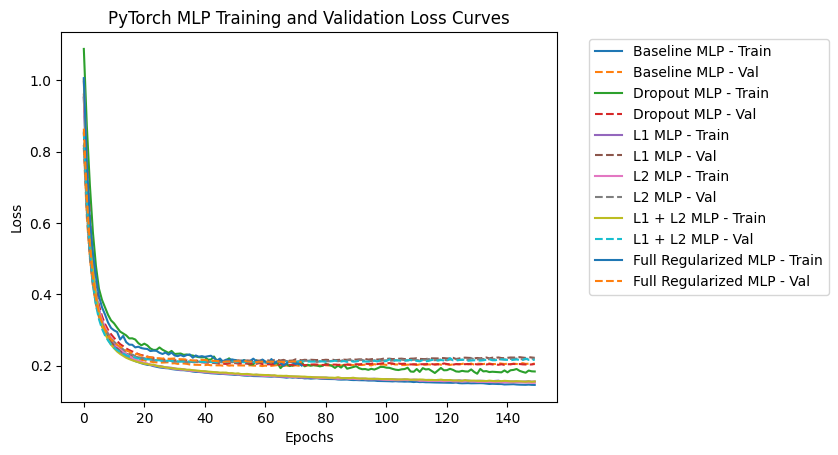

In [42]:
#############################
#       LOSS CURVES         #
#############################

for name, history in histories.items():
    plt.plot(history["train_loss"], label=f"{name} - Train")
    plt.plot(history["val_loss"], linestyle="--", label=f"{name} - Val")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("PyTorch MLP Training and Validation Loss Curves")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [43]:
#############################
#     COMPARISON TABLE      #
#############################

comparison_rows = []

for name, model in models.items():
    train_pred, _ = predict_model(model, X_train_full_tensor)
    test_pred, _ = predict_model(model, X_test_full_tensor)

    comparison_rows.append({
        "Model": name,
        "Train Accuracy": np.mean(train_pred == y_train_full),
        "Best Validation Accuracy": max(histories[name]["val_acc"]),
        "Test Accuracy": np.mean(test_pred == y_test_full),
        "Final Train Loss": histories[name]["train_loss"][-1],
        "Best Validation Loss": min(histories[name]["val_loss"])
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    by=["Best Validation Accuracy", "Best Validation Loss"],
    ascending=[False, True]
).reset_index(drop=True)

display(comparison_df)


,Model,Train Accuracy,Best Validation Accuracy,Test Accuracy,Final Train Loss,Best Validation Loss
0,Dropout MLP,0.931562,0.929688,0.9475,0.183474,0.201084
1,Baseline MLP,0.937813,0.923438,0.9500,0.145757,0.198147
2,L2 MLP,0.931875,0.921875,0.9375,0.151745,0.208538
3,Full Regularized MLP,0.921875,0.921875,0.9550,0.200009,0.209539
4,L1 + L2 MLP,0.935937,0.920312,0.9475,0.155471,0.208521
5,L1 MLP,0.931562,0.918750,0.9375,0.155298,0.212049


In [44]:
#############################
#    TRAINING EVALUATION    #
#############################

y_train_pred, _ = predict_model(best_model, X_train_full_tensor)
train_accuracy = np.mean(y_train_pred == y_train_full)

print("Training Accuracy:", train_accuracy)


Training Accuracy: 0.9315625


In [45]:
#############################
#        PREDICTION         #
#############################

y_pred, probabilities = predict_model(best_model, X_test_full_tensor)

print("Probabilities shape:", probabilities.shape)
print("Prediction shape:", y_pred.shape)


Probabilities shape: (400, 3)
Prediction shape: (400,)


In [46]:
#############################
#         ACCURACY          #
#############################

accuracy = np.mean(y_test_full == y_pred)
print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.9475


In [47]:
#############################
#    PER CLASS ACCURACY     #
#############################

for i in range(NUM_TARGET_CLASSES):
    k = (y_test_full == i)
    acc = np.mean(y_pred[k] == i) if np.sum(k) > 0 else 0.0
    print(f"Class {i} accuracy: {acc:.4f}")


Class 0 accuracy: 0.9706
Class 1 accuracy: 0.9586
Class 2 accuracy: 0.7037


In [48]:
#############################
#     CONFUSION MATRIX      #
#############################

# cm = confusion_matrix(y_test_full, y_pred)
# print(cm)

# disp = ConfusionMatrixDisplay(confusion_matrix=cm)
# disp.plot()
# plt.title("Confusion Matrix")
# plt.show()

cm = pd.crosstab(
    pd.Series(y_test_full, name="Actual"),
    pd.Series(y_pred, name="Predicted")
)
display(cm)


Predicted,0,1,2
Actual,,,
0,198,6,0
1,4,162,3
2,0,8,19


In [49]:
#############################
#  CLASSIFICATION REPORT    #
#############################

print(classification_report(y_test_full, y_pred, zero_division=0))


              precision    recall  f1-score   support

           0       0.98      0.97      0.98       204
           1       0.92      0.96      0.94       169
           2       0.86      0.70      0.78        27

    accuracy                           0.95       400
   macro avg       0.92      0.88      0.90       400
weighted avg       0.95      0.95      0.95       400



In [50]:
#############################
# PRECISION / RECALL / F1   #
#############################

macro_precision = precision_score(y_test_full, y_pred, average="macro", zero_division=0)
macro_recall = recall_score(y_test_full, y_pred, average="macro", zero_division=0)
macro_f1 = f1_score(y_test_full, y_pred, average="macro", zero_division=0)
weighted_f1 = f1_score(y_test_full, y_pred, average="weighted", zero_division=0)

print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall: {macro_recall:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")


Macro Precision: 0.9214
Macro Recall: 0.8776
Macro F1: 0.8967
Weighted F1: 0.9466


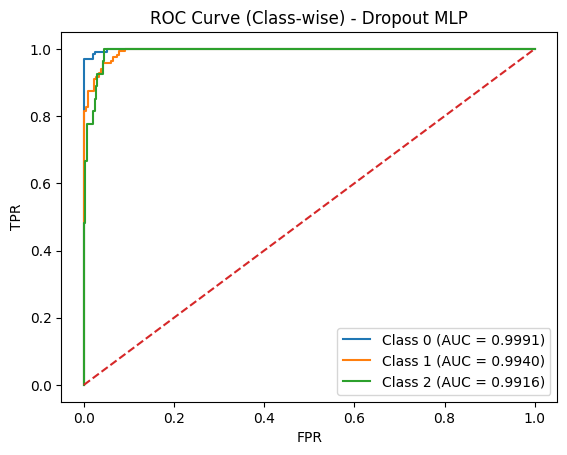

In [51]:
#############################
#   ROC CURVE (CLASS-WISE)  #
#############################

y_test_one_hot = label_binarize(y_test_full, classes=np.arange(NUM_TARGET_CLASSES))

for i in range(NUM_TARGET_CLASSES):
    fpr, tpr, _ = roc_curve(y_test_one_hot[:, i], probabilities[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], '--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title(f"ROC Curve (Class-wise) - {best_model_name}")
plt.legend()
plt.show()


In [52]:
#############################
#       K-FOLD SECTION      #
#############################

if RUN_KFOLD:
    X_full, y_full = preprocess_dataset(pd.read_csv(DATA_FILE))
    y_full = y_full.squeeze()

    skf = StratifiedKFold(n_splits=KFOLD_SPLITS, shuffle=True, random_state=42)
    fold_results = []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_full, y_full), start=1):
        print(f"\nFold {fold_idx}/{KFOLD_SPLITS}")

        X_fold_train = X_full.iloc[train_idx].reset_index(drop=True)
        y_fold_train = y_full.iloc[train_idx].reset_index(drop=True)
        X_val = X_full.iloc[val_idx].reset_index(drop=True)
        y_val = y_full.iloc[val_idx].reset_index(drop=True)

        if USE_AUGMENTATION:
            synth_n = len(X_fold_train) if N_SYNTH_SAMPLES is None else N_SYNTH_SAMPLES

            if USE_UNSCALED:
                X_fold_train_aug_raw, y_fold_train = augment_training_data_unscaled(
                    X_fold_train,
                    y_fold_train,
                    n_samples=synth_n
                )

                scaler = StandardScaler()
                X_fold_train_scaled = pd.DataFrame(
                    scaler.fit_transform(X_fold_train_aug_raw),
                    columns=X_full.columns
                )
                X_val_scaled = pd.DataFrame(
                    scaler.transform(X_val),
                    columns=X_full.columns
                )

            else:
                scaler = StandardScaler()
                X_fold_train_scaled = pd.DataFrame(
                    scaler.fit_transform(X_fold_train),
                    columns=X_full.columns
                )
                X_val_scaled = pd.DataFrame(
                    scaler.transform(X_val),
                    columns=X_full.columns
                )

                X_fold_train_scaled, y_fold_train = augment_training_data(
                    X_fold_train_scaled,
                    y_fold_train,
                    n_samples=synth_n
                )

        else:
            scaler = StandardScaler()
            X_fold_train_scaled = pd.DataFrame(
                scaler.fit_transform(X_fold_train),
                columns=X_full.columns
            )
            X_val_scaled = pd.DataFrame(
                scaler.transform(X_val),
                columns=X_full.columns
            )

        X_fold_split, X_fold_inner_val, y_fold_split, y_fold_inner_val = train_test_split(
            X_fold_train_scaled,
            y_fold_train,
            test_size=0.2,
            random_state=RANDOM_STATE,
            stratify=y_fold_train
        )

        X_fold_split_tensor = torch.tensor(np.array(X_fold_split), dtype=torch.float32)
        y_fold_split_tensor = torch.tensor(np.array(y_fold_split).ravel(), dtype=torch.long)
        X_fold_inner_val_tensor = torch.tensor(np.array(X_fold_inner_val), dtype=torch.float32)
        y_fold_inner_val_tensor = torch.tensor(np.array(y_fold_inner_val).ravel(), dtype=torch.long)

        train_dataset = TensorDataset(X_fold_split_tensor, y_fold_split_tensor)
        val_dataset = TensorDataset(X_fold_inner_val_tensor, y_fold_inner_val_tensor)

        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

        input_dim = X_fold_train_scaled.shape[1]
        models, histories = train_all_models(input_dim, train_loader, val_loader)

        validation_results = []
        for name, history in histories.items():
            validation_results.append([
                name,
                max(history["val_acc"]),
                min(history["val_loss"])
            ])

        validation_df = pd.DataFrame(
            validation_results,
            columns=["Model", "Best Validation Accuracy", "Best Validation Loss"]
        )

        best_model_name = validation_df.sort_values(
            by=["Best Validation Accuracy", "Best Validation Loss"],
            ascending=[False, True]
        ).iloc[0]["Model"]

        best_model = models[best_model_name]

        X_fold_train_tensor = torch.tensor(np.array(X_fold_train_scaled), dtype=torch.float32)
        X_val_tensor = torch.tensor(np.array(X_val_scaled), dtype=torch.float32)

        y_train_pred, _ = predict_model(best_model, X_fold_train_tensor)
        y_val_pred, _ = predict_model(best_model, X_val_tensor)

        train_acc = np.mean(y_train_pred == np.array(y_fold_train).ravel())
        val_acc = np.mean(y_val_pred == np.array(y_val).ravel())
        val_macro_f1 = f1_score(np.array(y_val).ravel(), y_val_pred, average="macro", zero_division=0)

        print(f"Best Model: {best_model_name}")
        print(f"Train Accuracy: {train_acc:.4f}")
        print(f"Validation Accuracy: {val_acc:.4f}")
        print(f"Validation Macro F1: {val_macro_f1:.4f}")

        fold_results.append({
            "fold": fold_idx,
            "best_model_name": best_model_name,
            "train_accuracy": train_acc,
            "val_accuracy": val_acc,
            "val_macro_f1": val_macro_f1
        })

    fold_df = pd.DataFrame(fold_results)
    display(fold_df)

    print(f"Average Train Accuracy: {fold_df['train_accuracy'].mean():.4f}")
    print(f"Average Validation Accuracy: {fold_df['val_accuracy'].mean():.4f}")
    print(f"Average Validation Macro F1: {fold_df['val_macro_f1'].mean():.4f}")

else:
    print("RUN_KFOLD is False, so this section is skipped.")



Fold 1/5
Early stopping at epoch 85
Best Model: Baseline MLP
Train Accuracy: 0.9375
Validation Accuracy: 0.9525
Validation Macro F1: 0.9202

Fold 2/5
Early stopping at epoch 72
Best Model: L1 MLP
Train Accuracy: 0.9387
Validation Accuracy: 0.9400
Validation Macro F1: 0.8803

Fold 3/5
Early stopping at epoch 94
Best Model: L1 + L2 MLP
Train Accuracy: 0.9431
Validation Accuracy: 0.9625
Validation Macro F1: 0.9456

Fold 4/5
Early stopping at epoch 120
Best Model: Dropout MLP
Train Accuracy: 0.9434
Validation Accuracy: 0.9550
Validation Macro F1: 0.9073

Fold 5/5
Early stopping at epoch 88
Best Model: L2 MLP
Train Accuracy: 0.9387
Validation Accuracy: 0.9575
Validation Macro F1: 0.9179


,fold,best_model_name,train_accuracy,val_accuracy,val_macro_f1
0,1,Baseline MLP,0.937500,0.9525,0.920219
1,2,L1 MLP,0.938750,0.9400,0.880285
2,3,L1 + L2 MLP,0.943125,0.9625,0.945587
3,4,Dropout MLP,0.943438,0.9550,0.907283
4,5,L2 MLP,0.938750,0.9575,0.917889


Average Train Accuracy: 0.9403
Average Validation Accuracy: 0.9535
Average Validation Macro F1: 0.9143
